In [1]:
print("Alhamdullilah")

Alhamdullilah


### Heart Disease Prediction using KNN and SVM
Predict whether a patient has heart disease based on medical attributes

1. Heart Disease Dataset
2. Understand Data
3. EDA
4. Data Cleaning
5. Feature / Target Separation
6. Train-Test Split
7. Feature Scaling
8. Train KNN Model
9. Tune K
10. Train SVM Model
11. Compare Models
12. Evaluate Results
13. Final Conclusion

In [3]:
# Load Dataset and understand dataset
import pandas as pd

df = pd.read_csv("data/Heart_Disease_Prediction.csv")

print(df.info())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


#### Exploratory Data Analysis(EDA)

In [5]:
# Check target distribution
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

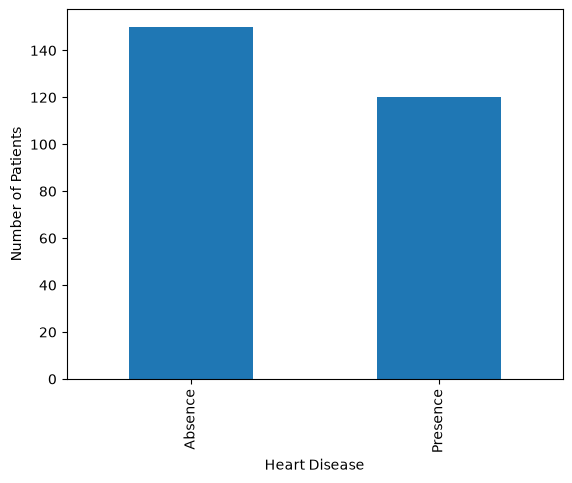

In [6]:
# Visualize the target distribution
import matplotlib.pyplot as plt

df['Heart Disease'].value_counts().plot(
    kind='bar'
)

plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')

plt.show()

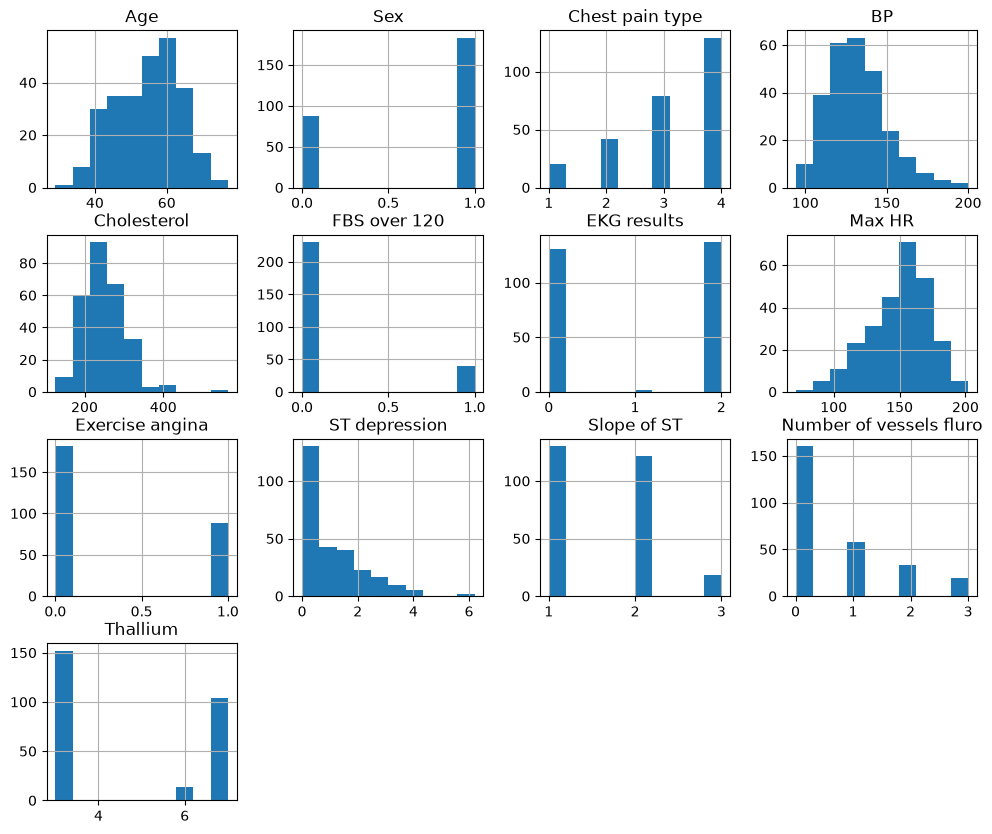

In [7]:
# Numerical Feature Distributions

df.hist(
    figsize=(12, 10)
)

plt.show()

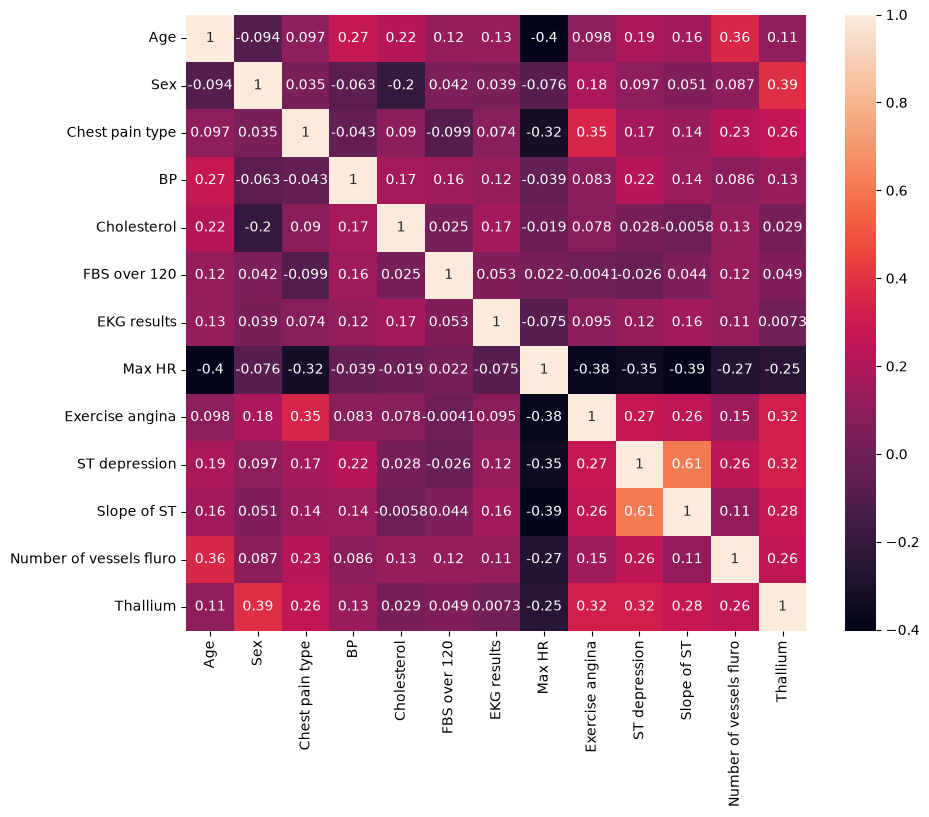

In [9]:
# Correlation Analysis
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True
)

plt.show()

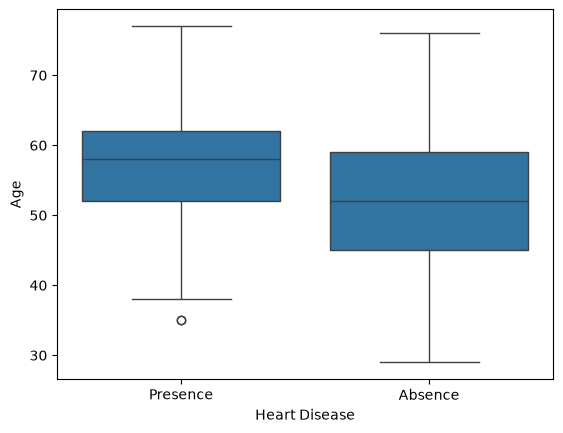

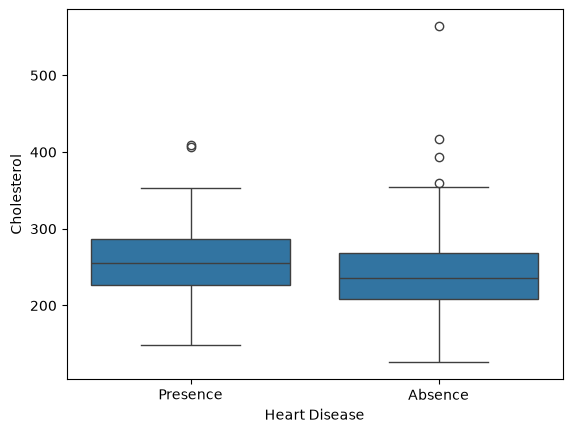

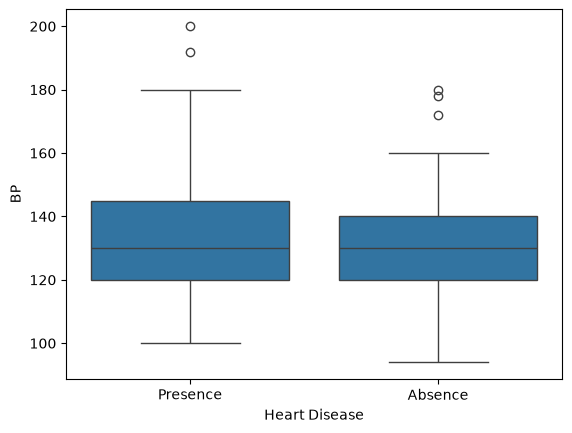

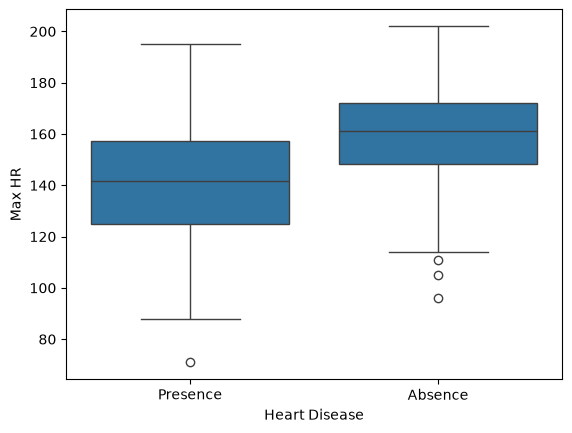

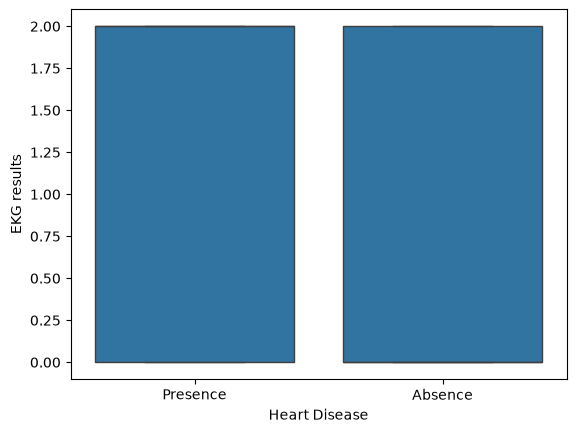

In [15]:
sns.boxplot(
    x='Heart Disease',
    y='Age',
    data=df
)
plt.show()
sns.boxplot(
    x='Heart Disease',
    y='Cholesterol',
    data=df
)
plt.show()
sns.boxplot(
    x='Heart Disease',
    y='BP',
    data=df
)
plt.show()
sns.boxplot(
    x='Heart Disease',
    y='Max HR',
    data=df
)
plt.show()
sns.boxplot(
    x='Heart Disease',
    y='EKG results',
    data=df
)
plt.show()

In [16]:
# Feature Selection
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

In [17]:
# Check categorical features
X.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X['Sex'] = encoder.fit_transform(
    X['Sex']
)
X['Sex'].describe()

count    270.000000
mean       0.677778
std        0.468195
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Sex, dtype: float64

In [21]:
# TT Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Train Data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Test Data
X_test_scaled = scaler.transform(
    X_test
)

# Verify data
X_train_scaled.shape
X_train_scaled[:5]

array([[-1.3361797 , -1.47528661, -0.10435568, -0.63795169, -0.76298149,
        -0.39380225, -1.05474207,  1.00746877, -0.68511879, -0.93924147,
         0.69812296, -0.70900762, -0.85615942],
       [-0.03903446,  0.67783439,  0.9202274 , -0.52273633,  0.73241188,
        -0.39380225,  0.95252037, -1.5511029 ,  1.4596009 ,  1.93715953,
         0.69812296,  1.43288953, -0.85615942],
       [-0.36332077, -1.47528661, -0.10435568, -0.63795169,  0.90719811,
        -0.39380225,  0.95252037,  0.28927321, -0.68511879, -0.39991629,
        -0.95896011, -0.70900762, -0.85615942],
       [ 1.58239708, -1.47528661, -2.15352185,  0.51420186, -0.1803607 ,
        -0.39380225, -1.05474207,  0.01994988, -0.68511879,  0.67873409,
        -0.95896011,  1.43288953, -0.85615942],
       [-0.03903446,  0.67783439, -0.10435568, -0.63795169,  0.18863247,
        -0.39380225,  0.95252037, -0.15959901, -0.68511879, -0.57969135,
         0.69812296, -0.70900762,  1.21589027]])

#### Train K-Nearest Neighbors (KNN) Model

In [37]:
# Understanding KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=14
)

knn.fit( X_train_scaled, y_train)

# Make prediction
y_pred = knn.predict(X_test_scaled)

y_pred

array(['Absence', 'Absence', 'Absence', 'Presence', 'Absence', 'Absence',
       'Absence', 'Presence', 'Presence', 'Presence', 'Absence',
       'Absence', 'Absence', 'Presence', 'Presence', 'Presence',
       'Absence', 'Presence', 'Absence', 'Presence', 'Absence',
       'Presence', 'Absence', 'Absence', 'Absence', 'Presence', 'Absence',
       'Absence', 'Absence', 'Presence', 'Absence', 'Presence',
       'Presence', 'Absence', 'Absence', 'Absence', 'Presence', 'Absence',
       'Absence', 'Absence', 'Presence', 'Absence', 'Presence',
       'Presence', 'Presence', 'Absence', 'Absence', 'Presence',
       'Presence', 'Presence', 'Presence', 'Presence', 'Absence',
       'Presence'], dtype=object)

In [38]:
# Evaluate model
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

classification = classification_report(
    y_test,
    y_pred
)

print(accuracy)
print(classification)

0.8703703703703703
              precision    recall  f1-score   support

     Absence       0.90      0.87      0.88        30
    Presence       0.84      0.88      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.87      0.87        54
weighted avg       0.87      0.87      0.87        54



In [39]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[26  4]
 [ 3 21]]


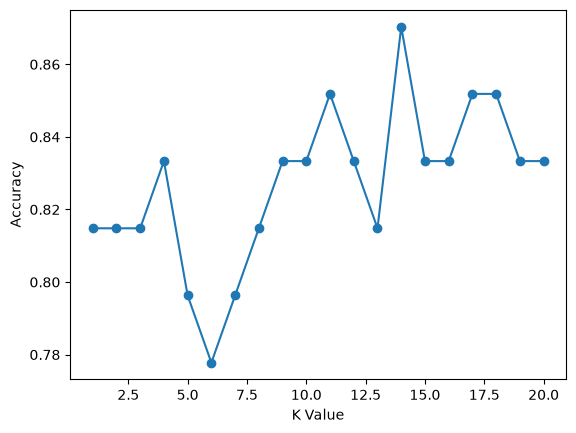

In [41]:
# Choosing the best K
accuracy_scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    score = model.score(
        X_test_scaled,
        y_test
    )

    accuracy_scores.append(score)

# plt.figure(figsize=(20,10))
plt.plot(
    range(1,21),
    accuracy_scores,
    marker='o'
)

plt.xlabel('K Value')
plt.ylabel('Accuracy')

plt.show()

#### Train Support Vector Machine Model
SVM tries to find the best boundary that separates classes.

In [49]:
from sklearn.svm import SVC

# Train basic SVM model
svm = SVC(
    # We can choose different kernel
    # Ex: linear, rbf(RBF Kernel)
    kernel='linear',
    C=1,
    gamma='scale'
)

svm.fit(
    X_train_scaled,
    y_train
)

# Make predictions

y_pred_svm = svm.predict(
    X_test_scaled
)

In [50]:
# Evaluate SVM
from sklearn.metrics import (accuracy_score, classification_report)

accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

cr = classification_report(
    y_test,
    y_pred_svm
)
print(accuracy)
print(cr)

0.8518518518518519
              precision    recall  f1-score   support

     Absence       0.89      0.83      0.86        30
    Presence       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



#### Create model comparison

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred)*100,
    "Precision": precision_score(y_test, y_pred, pos_label='Presence')*100,
    "Recall": recall_score(y_test, y_pred, pos_label='Presence')*100,
    "F1 Score": f1_score(y_test, y_pred, pos_label='Presence')*100
})

results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm)*100,
    "Precision": precision_score(y_test, y_pred_svm, pos_label='Presence')*100,
    "Recall": recall_score(y_test, y_pred_svm, pos_label='Presence')*100,
    "F1 Score": f1_score(y_test, y_pred_svm, pos_label='Presence')*100
})

comparison = pd.DataFrame(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,87.037037,84.000000,87.5,85.714286
1,SVM,85.185185,80.769231,87.5,84.000000


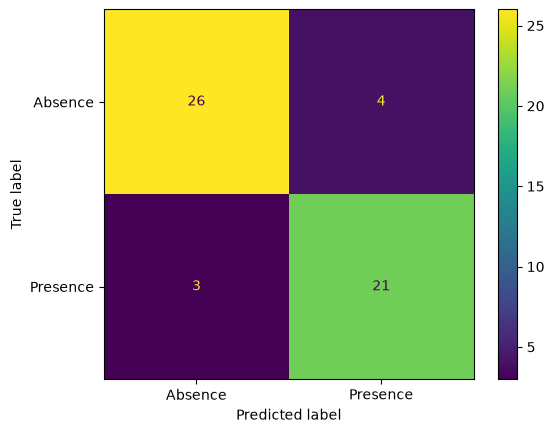

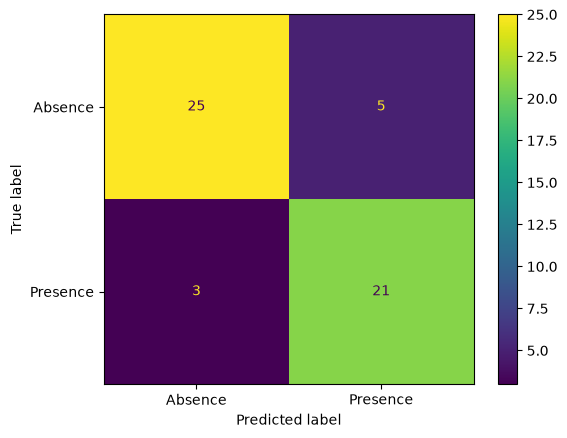

In [59]:
# Compare Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred
)

plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_svm
)

plt.show()